In [1]:
# ==================================================
# 1. THƯ VIỆN CƠ BẢN (DATA MANIPULATION & VIZ)
# ==================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import matplotlib.dates as mdates
from tqdm import tqdm

# Tắt các cảnh báo phiền phức
warnings.filterwarnings('ignore')

# ==================================================
# 2. LOAD CẤU HÌNH & KHÓA RANDOM SEED (QUAN TRỌNG)
# ==================================================
import src.config as config

# Khóa tính ngẫu nhiên ngay tại đây để kết quả Train luôn nhất quán
config.seed_everything(42) 

# ==================================================
# 3. MACHINE LEARNING & EVALUATION
# ==================================================
import xgboost as xgb
from xgboost.callback import EarlyStopping
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==================================================
# 4. OPTIMIZATION & MODULES TỰ VIẾT
# ==================================================
import optuna
from optuna.samplers import TPESampler

# Đảm bảo các file .py này nằm cùng thư mục với notebook
import src.fe as fe
import src.ml_model as ml_model
import src.train_utils as train_utils
import src.data_utils as data_utils
import src.dl_model as dl_model

print("\n✅ Đã import đầy đủ thư viện và kích hoạt Config!")

# 1. Đọc dữ liệu
btc = pd.read_csv(config.DATA_PATH, index_col=0, parse_dates=True)
df_base = fe.build_dataset(btc, task="regression")
print(f"Kích thước Base DataFrame: {df_base.shape}")

🌱 Đã set Seed: 42 | Thiết bị: cuda

✅ Đã import đầy đủ thư viện và kích hoạt Config!
🛠 Đang khởi tạo Pipeline Feature Engineering...
⏳ Đang tạo các đặc trưng Chu kỳ thời gian (Cyclical Time)...
📈 Đang tạo các đặc trưng Lags và Rolling ...
📥 Load Multi-TDA features từ cache...
🏁 Hoàn tất! Dataset sẵn sàng với 147 đặc trưng.
Kích thước Base DataFrame: (3073, 147)


In [2]:
# ==================================================
# CELL 2: PHÂN RỔ FEATURES VÀ NIÊM PHONG TẬP TEST
# ==================================================
print("✂️ Đang chia tách dữ liệu (Train/Val vs Hold-out Test)...")

# 1. Đảm bảo index của mày đang là kiểu Datetime
if not isinstance(df_base.index, pd.DatetimeIndex):
    df_base.index = pd.to_datetime(df_base.index)

# ---------------------------------------------------------
# 2. XÁC ĐỊNH 3 RỔ FEATURES (P1, P2, P3)
# ---------------------------------------------------------
# Tách riêng các cột Target (Mục tiêu dự báo) để không bị nhầm lẫn
target_cols = [c for c in df_base.columns if 'target' in c.lower()]
all_features = [c for c in df_base.columns if c not in target_cols]

# Lọc TDA và Finance
tda_keywords = ['tda', 'betti', 'entropy', 'amplitude', 'persistence']
tda_features = [c for c in all_features if any(kw in c.lower() for kw in tda_keywords)]
finance_features = [c for c in all_features if c not in tda_features]

# Lưu vào Dictionary để tiện gọi tên lúc Train
feature_sets = {
    'P1_Finance_Only': finance_features,
    'P2_TDA_Only': tda_features,
    'P3_Hybrid': all_features
}

print("\n📊 Đã gom xong 3 rổ Features:")
print(f"   🔵 P1 (Finance-Only) : {len(feature_sets['P1_Finance_Only'])} features")
print(f"   🔴 P2 (TDA-Only)     : {len(feature_sets['P2_TDA_Only'])} features")
print(f"   🟣 P3 (Hybrid)       : {len(feature_sets['P3_Hybrid'])} features")

# ---------------------------------------------------------
# 3. CHIA TÁCH THÀNH 2 CỤC "MẸ" THEO THỜI GIAN
# ---------------------------------------------------------
# Dùng df_base (chứa TẤT CẢ mọi thứ) để chia
df_train_val = df_base[df_base.index < '2025-01-01'].copy()
df_test = df_base[df_base.index >= '2025-01-01'].copy()

print(f"\n📦 Cục 1 (Train/Val) : {len(df_train_val)} dòng | Từ {df_train_val.index[0].date()} đến {df_train_val.index[-1].date()}")
print(f"📦 Cục 2 (Test)      : {len(df_test)} dòng | Từ {df_test.index[0].date()} đến {df_test.index[-1].date()}")
print("✅ Đã niêm phong tập Test thành công!")

✂️ Đang chia tách dữ liệu (Train/Val vs Hold-out Test)...

📊 Đã gom xong 3 rổ Features:
   🔵 P1 (Finance-Only) : 81 features
   🔴 P2 (TDA-Only)     : 63 features
   🟣 P3 (Hybrid)       : 144 features

📦 Cục 1 (Train/Val) : 2632 dòng | Từ 2017-10-18 đến 2024-12-31
📦 Cục 2 (Test)      : 441 dòng | Từ 2025-01-01 đến 2026-03-17
✅ Đã niêm phong tập Test thành công!


In [3]:
# ==================================================
# CELL 3: CẤU HÌNH HORIZON & CHỌN RỔ FEATURE ĐỂ CHẠY
# ==================================================
# 1d horizon -> 7d lookback
# 7d horizon -> 30d lookback
horizon_config = {
    '1d': {'horizon': 1, 'lookback': 7, 'target_col': 'target_1d'},
    '7d': {'horizon': 7, 'lookback': 30, 'target_col': 'target_7d'},
    '14d': {'horizon': 14, 'lookback': 60, 'target_col': 'target_14d'}
}

# ---------------------------------------------------------
# CHỌN RỔ FEATURE ĐỂ CHẠY (QUAN TRỌNG)
# ---------------------------------------------------------
# Vì mục tiêu của chuỗi này là chạy Finance Features, ta gọi rổ P1 ra:
base_features = feature_sets['P1_Finance_Only']

print(f"🎯 Đã load xong Config (Horizon & Lookback).")
print(f"✅ Đang kích hoạt RỔ FEATURE: P3_Hybrid ({len(all_features)} features).")
print(f"   (Các Cell Optuna và Train bên dưới sẽ chỉ nhìn thấy rổ này!)")

🎯 Đã load xong Config (Horizon & Lookback).
✅ Đang kích hoạt RỔ FEATURE: P3_Hybrid (144 features).
   (Các Cell Optuna và Train bên dưới sẽ chỉ nhìn thấy rổ này!)


In [4]:
# ==================================================
# CELL 4: GỌI ALL FEATURES
# ==================================================
all_features = feature_sets['P3_Hybrid']
print(f"✅ Đang kích hoạt RỔ FEATURE: P3_Hybrid ({len(all_features)} features).")

✅ Đang kích hoạt RỔ FEATURE: P3_Hybrid (144 features).


In [5]:
# ==================================================
# CELL 5: HUẤN LUYỆN VỚI PURGED WALK-FORWARD CV
# ==================================================

results_dict = {}

for name, params in horizon_config.items():
    print(f"\n{'='*50}")
    print(f"🚀 BẮT ĐẦU HUẤN LUYỆN HORIZON: {name} (Lookback: {params['lookback']} ngày)")
    print(f"{'='*50}")
    
    target_col = params['target_col']
    horizon_gap = params['horizon']
    
    # 1. Chuẩn bị data theo lookback
    df_lookback, lookback_feature_cols = ml_model.create_lookback_dataset(
        df_train_val, 
        feature_cols=all_features, 
        target_col=target_col, 
        lookback=params['lookback']
    )
    
    X = df_lookback[lookback_feature_cols]
    y = df_lookback[target_col]
    
    # 2. Setup Walk-Forward Validation (Purged TimeSeriesSplit)
    # Gap = horizon để chắc chắn Train không chứa data của Val
    n_splits = 5
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=int(len(X) * 0.15), gap=horizon_gap)
    
    fold = 1
    fold_metrics = []
    
    # BỔ SUNG: Khởi tạo list để lưu feature importances của tất cả các fold
    all_fold_importances = [] 
    
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        
        # Khởi tạo mô hình
        model = ml_model.get_xgboost_model(task="regression")
        model.set_params(early_stopping_rounds=30)
        
        # Fit model
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )
        
        # BỔ SUNG: Lưu trữ importance của fold hiện tại
        all_fold_importances.append(model.feature_importances_)
        
        # Predict & Evaluate
        y_pred = model.predict(X_val)
        metrics = ml_model.evaluate_model(y_val, y_pred)
        current_mae = mean_absolute_error(y_val, y_pred)
        metrics['MAE'] = current_mae
        
        fold_metrics.append(metrics)
        print(f"Fold {fold} | Val Dates: {X_val.index[0].date()} to {X_val.index[-1].date()} | MAE: {current_mae:.4f} | RMSE: {metrics['RMSE']:.4f}")
        fold += 1
        
    # Tính trung bình các folds
    avg_mae = np.mean([m['MAE'] for m in fold_metrics])
    avg_rmse = np.mean([m['RMSE'] for m in fold_metrics])
    print(f"🔥 KẾT QUẢ {name} - Avg Walk-Forward | MAE: {avg_mae:.4f} | RMSE: {avg_rmse:.4f}")
    
    # 3. Lấy Feature Importance (TRUNG BÌNH CỦA TẤT CẢ CÁC FOLDS)
    # BỔ SUNG: Tính trung bình theo từng feature dọc theo các fold (axis=0)
    avg_importances = np.mean(all_fold_importances, axis=0)
    importance_dict = dict(zip(lookback_feature_cols, avg_importances))
    
    # Sắp xếp từ cao xuống thấp
    sorted_importances = dict(sorted(importance_dict.items(), key=lambda item: item[1], reverse=True))
    top_30_names = list(sorted_importances.keys())[:30]
    
    results_dict[horizon_gap] = {
        'top_features': top_30_names,
        'feature_importances': sorted_importances,
        'metrics': fold_metrics
    }

print("\nĐã train xong tất cả các Horizon!")


🚀 BẮT ĐẦU HUẤN LUYỆN HORIZON: 1d (Lookback: 7 ngày)
🛠 Creating Lookback Data: Horizon target 'target_1d' | Lookback = 7 days
Fold 1 | Val Dates: 2019-08-16 to 2020-09-11 | MAE: 0.0239 | RMSE: 0.0418
Fold 2 | Val Dates: 2020-09-12 to 2021-10-09 | MAE: 0.0301 | RMSE: 0.0412
Fold 3 | Val Dates: 2021-10-10 to 2022-11-06 | MAE: 0.0240 | RMSE: 0.0338
Fold 4 | Val Dates: 2022-11-07 to 2023-12-04 | MAE: 0.0158 | RMSE: 0.0246
Fold 5 | Val Dates: 2023-12-05 to 2024-12-31 | MAE: 0.0197 | RMSE: 0.0271
🔥 KẾT QUẢ 1d - Avg Walk-Forward | MAE: 0.0227 | RMSE: 0.0337

🚀 BẮT ĐẦU HUẤN LUYỆN HORIZON: 7d (Lookback: 30 ngày)
🛠 Creating Lookback Data: Horizon target 'target_7d' | Lookback = 30 days
Fold 1 | Val Dates: 2019-08-31 to 2020-09-23 | MAE: 0.0644 | RMSE: 0.1004
Fold 2 | Val Dates: 2020-09-24 to 2021-10-18 | MAE: 0.0894 | RMSE: 0.1143
Fold 3 | Val Dates: 2021-10-19 to 2022-11-12 | MAE: 0.0683 | RMSE: 0.0948
Fold 4 | Val Dates: 2022-11-13 to 2023-12-07 | MAE: 0.0448 | RMSE: 0.0657
Fold 5 | Val Dates:

📊 ĐANG VẼ BIỂU ĐỒ SỨC MẠNH ĐẶC TRƯNG (FEATURE IMPORTANCE)...


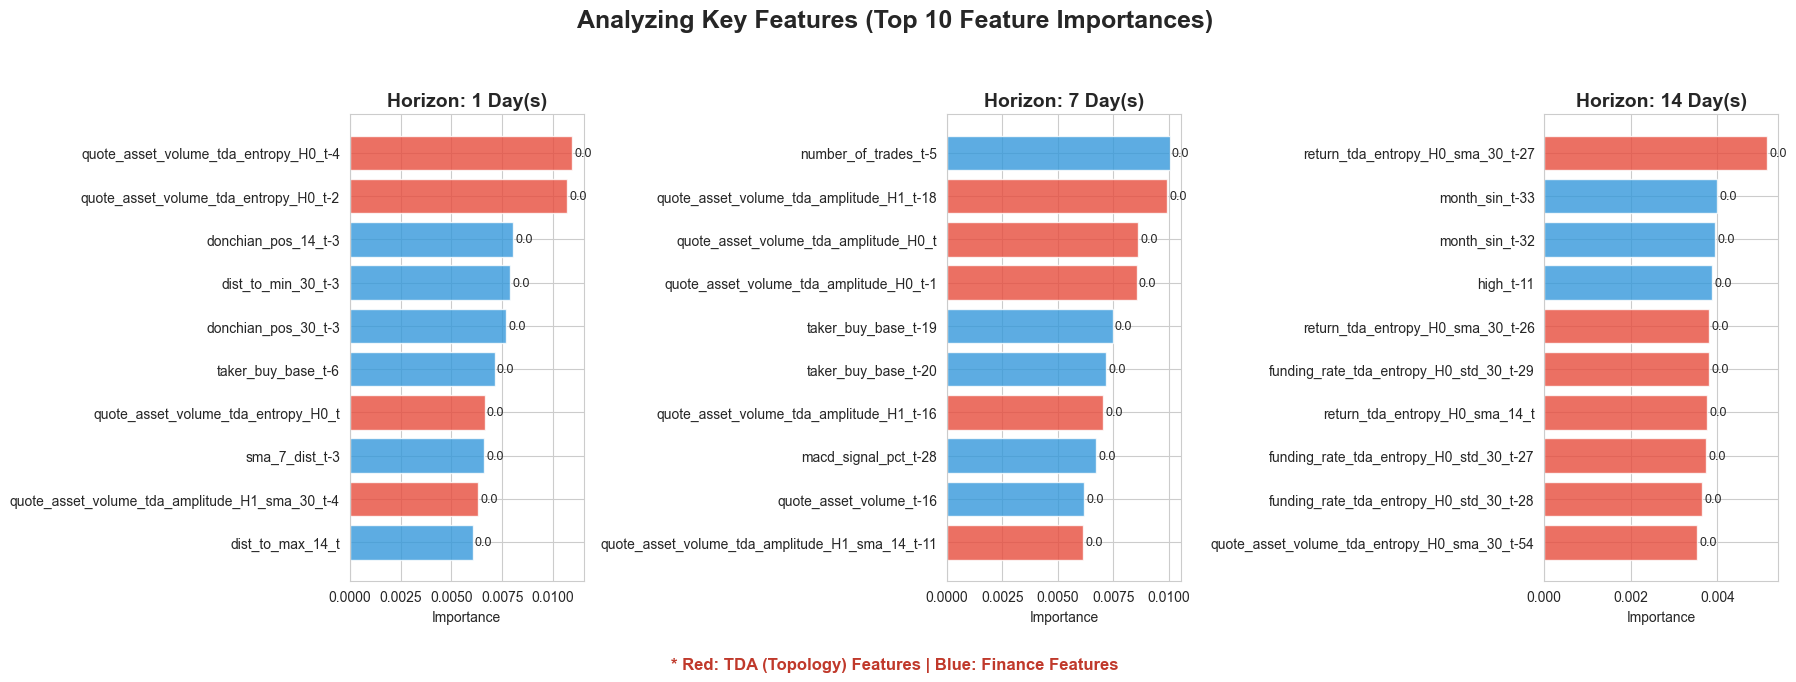

✅ Đã hoàn tất xuất biểu đồ Feature Importance!


In [6]:
# ==================================================
# CELL 6: TRỰC QUAN HÓA FEATURE IMPORTANCE (All Features)
# ==================================================
print("📊 ĐANG VẼ BIỂU ĐỒ SỨC MẠNH ĐẶC TRƯNG (FEATURE IMPORTANCE)...")

# Lấy danh sách các horizons trực tiếp từ biến config ở Cell 3
horizons_to_plot = [horizon_config['1d']['horizon'], horizon_config['7d']['horizon'], horizon_config['14d']['horizon']]

# Gọi hàm plot từ module tự viết
fe.plot_feature_importance_analysis(results_dict, horizons_to_plot)

print("✅ Đã hoàn tất xuất biểu đồ Feature Importance!")

In [7]:
# ==================================================
# CELL 16: TỐI ƯU HYPERPARAMETERS (OPTUNA)
# ==================================================

# Tắt bớt log rác của Optuna cho màn hình đỡ trôi
optuna.logging.set_verbosity(optuna.logging.WARNING)


# 1. Hàm mục tiêu cho Optuna (Objective Function)
def objective(trial, X, y, horizon_gap):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True), # L2
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),  # L1
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }
   
    # Dùng Purged TimeSeriesSplit giống hệt lúc đánh giá Baseline
    tscv = TimeSeriesSplit(n_splits=3, test_size=int(len(X) * 0.15), gap=horizon_gap)
    rmses = []
    maes = [] # Thêm list để lưu MAE
   
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
       
        # Đưa early_stopping_rounds vào tham số khởi tạo Model (Đã fix lỗi API)
        model = xgb.XGBRegressor(**param, early_stopping_rounds=30)
       
        # Fit model
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
       
        preds = model.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
        maes.append(mean_absolute_error(y_val, preds))
        
    # Lưu MAE trung bình vào "túi phụ" của trial này
    trial.set_user_attr("mae", np.mean(maes))
       
    return np.mean(rmses)


# 2. VÒNG LẶP TUNING SỬ DỤNG TẬP TRAIN_VAL
best_configs = {}
xgb_studies = {}

print("⚙️ KHỞI ĐỘNG OPTUNA TUNING (SỬ DỤNG ALL FEATURES)...")

for name, params in horizon_config.items():
    print(f"\n🎯 Đang tìm Param tối ưu cho Horizon: {name} (100 Trials)")
   
    target_col = params['target_col']
    horizon_val = params['horizon']
   
    # Lấy danh sách Top 30 features tinh hoa (Cell 4)
    top_30_features = results_dict[horizon_val]['top_features'][:30]
   
    # Tạo data Lookback (Nhớ là chỉ dùng df_train_val để không chạm vào tập Test)
    df_lookback, _ = ml_model.create_lookback_dataset(
        df_train_val,
        feature_cols=all_features,
        target_col=target_col,
        lookback=params['lookback']
    )
   
    # Lọc lấy X (chỉ gồm top 30 features) và y
    X_filtered = df_lookback[top_30_features]
    y_filtered = df_lookback[target_col]
   
    # Khởi tạo Study và chạy tối ưu (TPESampler là thuật toán tìm kiếm thông minh)
    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
   
    # Chạy 100 vòng (Có thể giảm n_trials=50 nếu muốn chạy lẹ hơn)
    study.optimize(lambda trial: objective(trial, X_filtered, y_filtered, horizon_val), n_trials=100)
    
    # Lấy MAE từ best trial ra để in
    best_mae = study.best_trial.user_attrs["mae"]
   
    print(f"   ✅ Best Trial ({name}): RMSE = {study.best_value:.4f} | MAE = {best_mae:.4f}")
   
    # Lưu lại Param xịn nhất
    best_configs[name] = {
        'best_params': study.best_params,
        'selected_features': top_30_features
    }
    
    xgb_studies[name] = study

print("\n🎉 HOÀN TẤT TUNING CHO TẤT CẢ HORIZON!")

⚙️ KHỞI ĐỘNG OPTUNA TUNING (SỬ DỤNG ALL FEATURES)...

🎯 Đang tìm Param tối ưu cho Horizon: 1d (100 Trials)
🛠 Creating Lookback Data: Horizon target 'target_1d' | Lookback = 7 days
   ✅ Best Trial (1d): RMSE = 0.0285 | MAE = 0.0198

🎯 Đang tìm Param tối ưu cho Horizon: 7d (100 Trials)
🛠 Creating Lookback Data: Horizon target 'target_7d' | Lookback = 30 days
   ✅ Best Trial (7d): RMSE = 0.0759 | MAE = 0.0556

🎯 Đang tìm Param tối ưu cho Horizon: 14d (100 Trials)
🛠 Creating Lookback Data: Horizon target 'target_14d' | Lookback = 60 days
   ✅ Best Trial (14d): RMSE = 0.1062 | MAE = 0.0802

🎉 HOÀN TẤT TUNING CHO TẤT CẢ HORIZON!


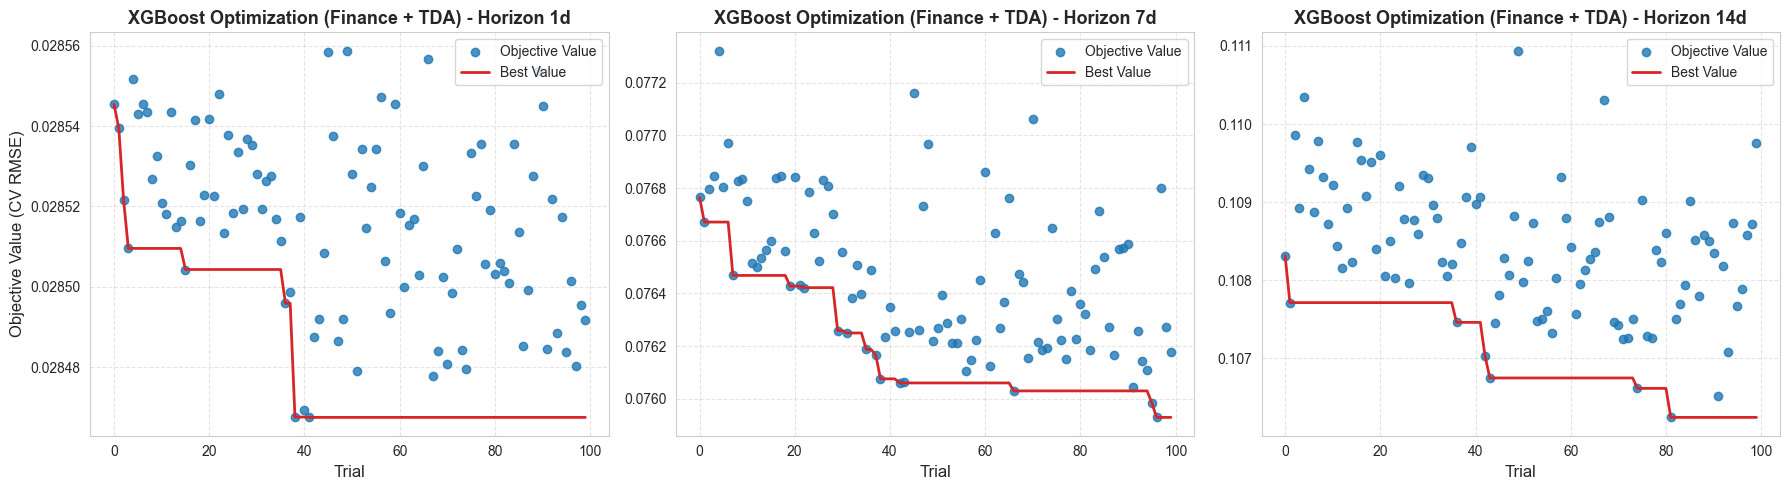

In [8]:
# ==================================================
# CELL 7: VẼ LƯỚI 3 BIỂU ĐỒ OPTIMIZATION HISTORY CỦA XGBOOST (THỦ CÔNG, CHỐNG LỖI)
# ==================================================

import matplotlib.pyplot as plt
import numpy as np

# Lấy danh sách các horizon đã lưu trong túi 
horizons = list(xgb_studies.keys())

# Khởi tạo khung 1 hàng, 3 cột. Kích thước 18x5 dàn ngang Word
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(horizons):
    ax = axes[i]
    study = xgb_studies[name]
    
    # --- BƯỚC MỚI: TỰ TRÍCH XUẤT DATA TỪ STUDY ĐỂ TỰ VẼ ---
    # Lấy danh sách các Trials đã chạy thành công
    completed_trials = [t for t in study.trials if t.value is not None]
    
    # Lấy số thứ tự Trial và Giá trị RMSE của Trial đó
    trial_nums = [t.number for t in completed_trials]
    values = [t.value for t in completed_trials]
    
    # Tự tính cái đường "Best Value" (là giá trị nhỏ nhất tính tới thời điểm hiện tại)
    best_values = np.minimum.accumulate(values)
    # ------------------------------------------------------
    
    # Vẽ các chấm xanh (Từng thử nghiệm của Optuna)
    ax.scatter(trial_nums, values, color='#1f77b4', alpha=0.8, label='Objective Value')
    
    # Vẽ đường đỏ bậc thang (Giá trị xịn nhất Optuna tìm được)
    ax.plot(trial_nums, best_values, color='#d62728', linewidth=2, label='Best Value')
    
    # Trang trí chuẩn học thuật 
    ax.set_title(f'XGBoost Optimization (Finance + TDA) - Horizon {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Trial', fontsize=12)
    
    # Chỉ hiện chữ ở trục Y cho biểu đồ đầu tiên
    if i == 0:
        ax.set_ylabel('Objective Value (CV RMSE)', fontsize=12)
        
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Nhớ bỏ comment để lưu ảnh độ phân giải cao cho báo cáo nhé
# plt.savefig('xgboost_optuna_history_manual.png', dpi=300, bbox_inches='tight')

plt.show()

In [9]:
# ==================================================
# CELL 8: HUẤN LUYỆN MODEL FINAL BẰNG TẬP TRAIN_VAL
# ==================================================

final_models = {}

for name, best_data in best_configs.items():
    print(f"🔨 Training Final Model for {name}...")
    
    params = horizon_config[name]
    target_col = params['target_col']
    top_features = best_data['selected_features']
    
    # Chuẩn bị dữ liệu cuối cùng
    df_lb, _ = ml_model.create_lookback_dataset(df_train_val, all_features, target_col, params['lookback'])
    X_final = df_lb[top_features]
    y_final = df_lb[target_col]
    
    # Train model với bộ tham số tối ưu nhất
    final_model = xgb.XGBRegressor(**best_data['best_params'])
    final_model.fit(X_final, y_final)
    
    final_models[name] = final_model
    print(f"⭐ Model {name} đã sẵn sàng!")


# 4. Lưu model lại
#os.makedirs('models/xgb', exist_ok=True)
#joblib.dump(final_models, 'models/xgb/all_features_models.pkl')
#print("\n💾 Đã lưu toàn bộ Model All Features vào: 'models/xgb/all_features_models.pkl'")

🔨 Training Final Model for 1d...
🛠 Creating Lookback Data: Horizon target 'target_1d' | Lookback = 7 days
⭐ Model 1d đã sẵn sàng!
🔨 Training Final Model for 7d...
🛠 Creating Lookback Data: Horizon target 'target_7d' | Lookback = 30 days
⭐ Model 7d đã sẵn sàng!
🔨 Training Final Model for 14d...
🛠 Creating Lookback Data: Horizon target 'target_14d' | Lookback = 60 days
⭐ Model 14d đã sẵn sàng!



📈 ĐANG ĐÁNH GIÁ MODEL (ALL FEATURES) TRÊN TẬP TEST ...
🛠 Creating Lookback Data: Horizon target 'target_1d' | Lookback = 7 days
✅ RMSE của Horizon 1d: 0.0257 | MAE = 0.0183
🛠 Creating Lookback Data: Horizon target 'target_7d' | Lookback = 30 days
✅ RMSE của Horizon 7d: 0.0687 | MAE = 0.0540
🛠 Creating Lookback Data: Horizon target 'target_14d' | Lookback = 60 days
✅ RMSE của Horizon 14d: 0.0966 | MAE = 0.0774


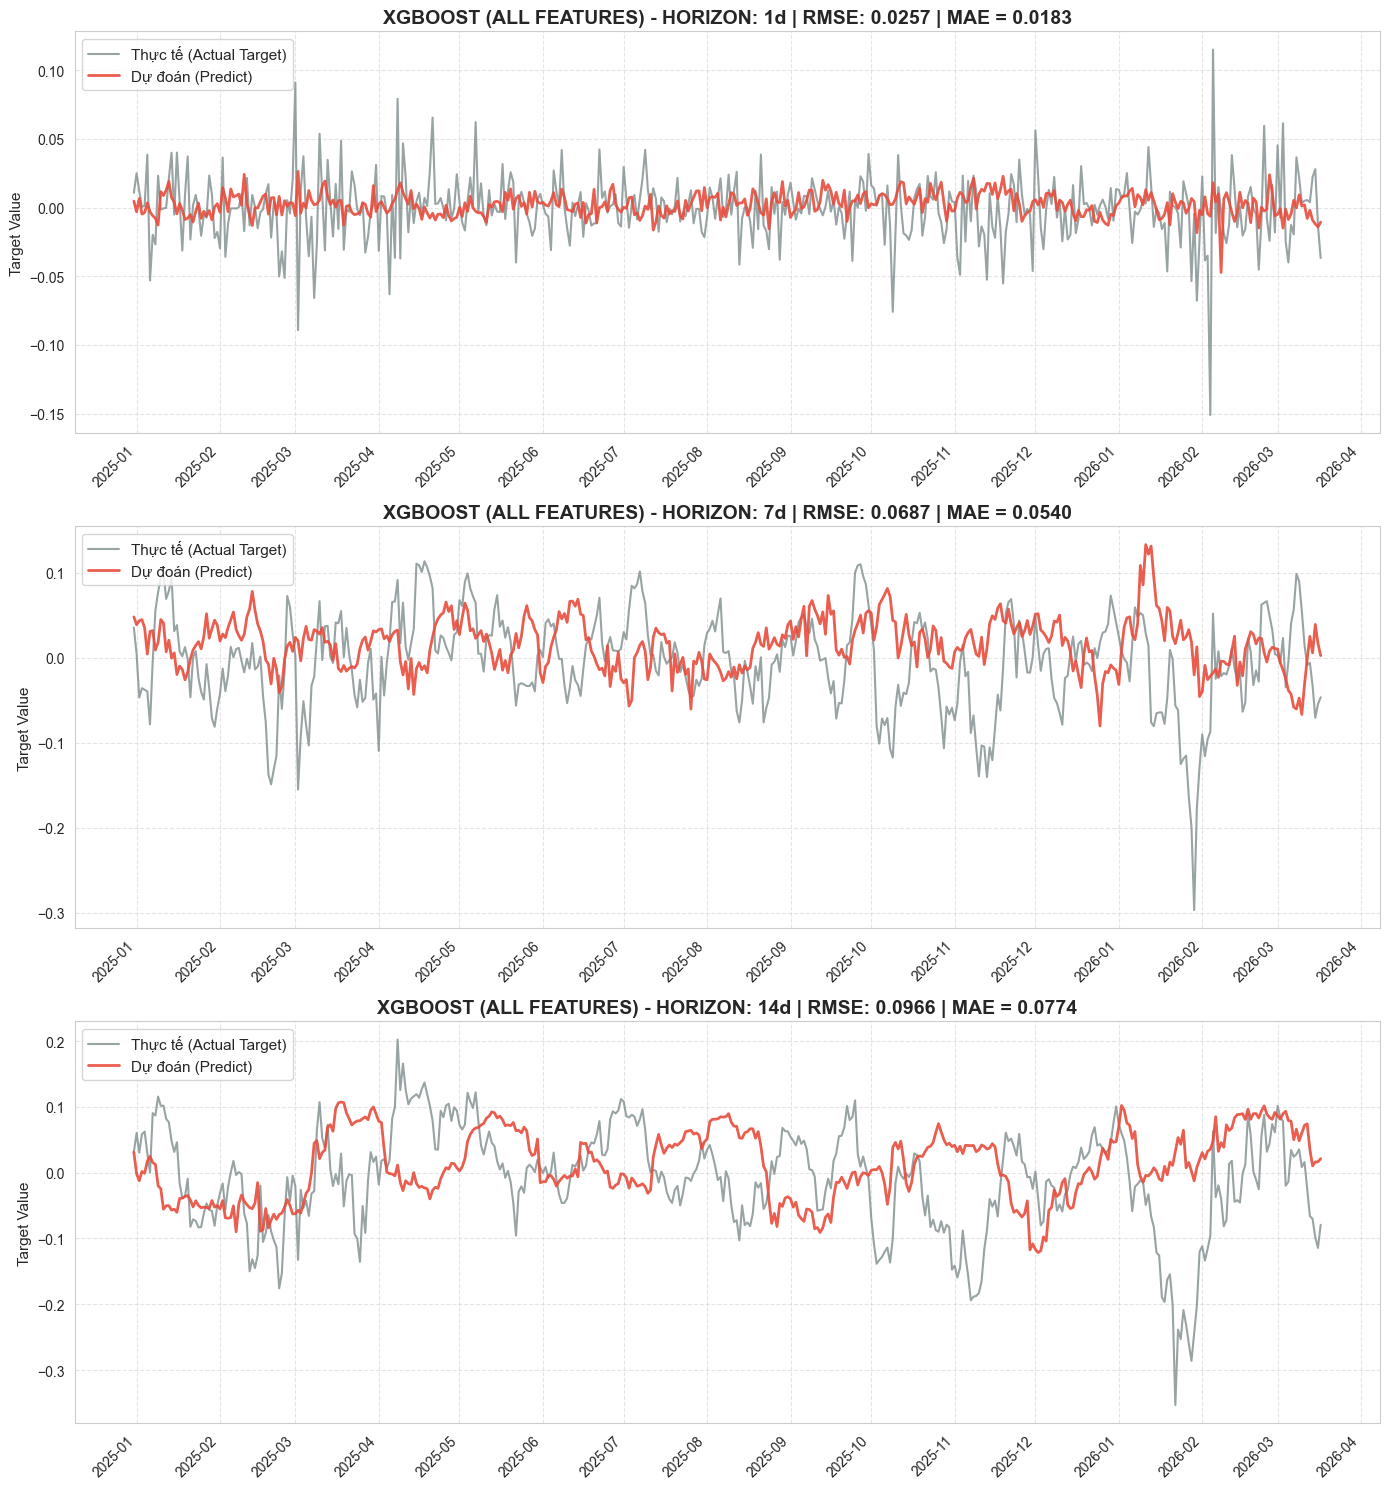

In [10]:
# ==================================================
# CELL 9: ĐÁNH GIÁ & VẼ BIỂU ĐỒ TRÊN TẬP TEST
# ==================================================

def evaluate_rmse_and_plot(final_models, best_configs, config, df_test):
    horizons = list(config.keys())
    
    # Tạo lưới biểu đồ xếp chồng (Mỗi horizon 1 dòng)
    fig, axes = plt.subplots(len(horizons), 1, figsize=(14, 5 * len(horizons)))
    if len(horizons) == 1:
        axes = [axes]
        
    print("\n📈 ĐANG ĐÁNH GIÁ MODEL (ALL FEATURES) TRÊN TẬP TEST ...")
    
    for i, name in enumerate(horizons):
        params = config[name]
        selected_features = best_configs[name]['selected_features']
        
        # 1. Chuẩn bị data cho tập Test
        lookback_days = params['lookback']
        tail_train_val = df_train_val.iloc[-lookback_days:]
        df_test_extended = pd.concat([tail_train_val, df_test])
        df_lb, _ = ml_model.create_lookback_dataset(df_test_extended, all_features, params['target_col'], params['lookback'])
        
        # Bỏ các dòng NaN chưa có đáp án tương lai
        df_lb = df_lb.dropna(subset=[params['target_col']])
        
        X_test = df_lb[selected_features]
        y_test = df_lb[params['target_col']]
        
        # 2. Dự đoán
        model = final_models[name]
        y_pred = model.predict(X_test)
        
        # 3. Tính RMSE, MAE
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        print(f"✅ RMSE của Horizon {name}: {rmse:.4f} | MAE = {mae:.4f}")
        
        # 4. Vẽ biểu đồ Line Chart
        ax = axes[i]
        
        # Đường Thực tế (Màu xám/xanh đen làm nền)
        ax.plot(y_test.index, y_test.values, label='Thực tế (Actual Target)', 
                color='#7f8c8d', alpha=0.8, linewidth=1.5)
        
        # Đường Dự đoán (Màu đỏ cho nổi)
        ax.plot(y_test.index, y_pred, label='Dự đoán (Predict)', 
                color='#e74c3c', alpha=0.9, linewidth=2)
        
        # Format trục X (Tháng/Năm)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # Gắn luôn RMSE và DA lên Title của từng biểu đồ để dễ báo cáo
        ax.set_title(f'XGBOOST (ALL FEATURES) - HORIZON: {name} | RMSE: {rmse:.4f} | MAE = {mae:.4f}', 
                     fontsize=14, fontweight='bold')
        ax.set_ylabel('Target Value', fontsize=11)
        ax.legend(loc='upper left', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Thực thi lệnh kiểm tra trên tập df_test
evaluate_rmse_and_plot(final_models, best_configs, horizon_config, df_test)

In [12]:
# ==================================================
# CELL 10: XUẤT DỮ LIỆU DỰ BÁO ĐỂ LÀM DM TEST
# ==================================================
import pandas as pd

print("💾 ĐANG LƯU DỮ LIỆU DỰ BÁO RA FILE CSV...")

horizons = list(horizon_config.keys())

for name in horizons:
    params = horizon_config[name]
    selected_features = best_configs[name]['selected_features']
    
    # 1. Tái tạo lại tập Test y hệt như lúc vẽ biểu đồ
    lookback_days = params['lookback']
    tail_train_val = df_train_val.iloc[-lookback_days:]
    df_test_extended = pd.concat([tail_train_val, df_test])
    df_lb, _ = ml_model.create_lookback_dataset(df_test_extended, all_features, params['target_col'], params['lookback'])
    
    # Bỏ các dòng NaN chưa có đáp án tương lai
    df_lb = df_lb.dropna(subset=[params['target_col']])
    
    X_test = df_lb[selected_features]
    y_test = df_lb[params['target_col']]
    
    # 2. Lấy dự báo từ final model
    model = final_models[name]
    y_pred = model.predict(X_test)
    
    # 3. Đóng gói vào DataFrame và xuất CSV
    df_export = pd.DataFrame({
        'Date': y_test.index,
        'y_true': y_test.values,
        'y_pred_xgb_hybrid': y_pred  # Tên cột rõ ràng để lát dễ so sánh
    })
    
    # Tên file động theo horizon (vd: preds_xgboost_finance_7d.csv)
    file_name = f'DB/test.preds_xgboost_hybrid_{name}.csv'
    df_export.to_csv(file_name, index=False)
    
    print(f"  ✅ Đã lưu thành công: {file_name} (Số lượng Test: {len(df_export)} dòng)")

print("-" * 50)
print("🎉 Hoàn tất việc xuất file cho mô hình XGBoost (Finance + TDA)!")

💾 ĐANG LƯU DỮ LIỆU DỰ BÁO RA FILE CSV...
🛠 Creating Lookback Data: Horizon target 'target_1d' | Lookback = 7 days
  ✅ Đã lưu thành công: DB/test.preds_xgboost_hybrid_1d.csv (Số lượng Test: 442 dòng)
🛠 Creating Lookback Data: Horizon target 'target_7d' | Lookback = 30 days
  ✅ Đã lưu thành công: DB/test.preds_xgboost_hybrid_7d.csv (Số lượng Test: 442 dòng)
🛠 Creating Lookback Data: Horizon target 'target_14d' | Lookback = 60 days
  ✅ Đã lưu thành công: DB/test.preds_xgboost_hybrid_14d.csv (Số lượng Test: 442 dòng)
--------------------------------------------------
🎉 Hoàn tất việc xuất file cho mô hình XGBoost (Finance + TDA)!


In [ ]:
# ==================================================
# CELL 11: ĐẠI VÒNG LẶP HUẤN LUYỆN LSTM (ALL HORIZONS)
# ==================================================

device = config.DEVICE
print(f"🚀 Hệ thống sẵn sàng! Chạy trên: {device}")

# Dictionary lưu trữ toàn bộ model và kết quả để xíu nữa vẽ biểu đồ
final_dl_models = {}
test_results = {}
best_hyperparams_dict = {}
lstm_histories = {} 

for h_key in config.HORIZONS:
    config.seed_everything(42)
    settings = config.HORIZON_SETTINGS[h_key]
    target_col = f'target_{h_key}d'
    lookback = settings['time_steps']
    
    print(f"\n" + "="*70)
    print(f"🚀 ĐANG XỬ LÝ HORIZON: {h_key} NGÀY (Lookback: {lookback} ngày)")
    print("="*70)

    # ---------------------------------------------------------
    # BƯỚC 1: CROSS VALIDATION (5-FOLDS) TRÊN TẬP TRAIN_VAL
    # ---------------------------------------------------------
    print(f"🧬 [1/3] Đang chạy Cross-Validation 5 Folds...")
    tscv = TimeSeriesSplit(n_splits=config.N_SPLITS)
    fold_rmses = []
    fold_maes = []
    
    # Thanh tiến trình cho từng Horizon
    pbar = tqdm(total=config.N_SPLITS, desc=f"CV {h_key}d", leave=False)
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(df_train_val)):
        df_tr, df_val = df_train_val.iloc[train_idx], df_train_val.iloc[val_idx]
        
        train_loader, val_loader, *_ = data_utils.prepare_dataloaders(
            df_tr[all_features], df_tr[target_col],
            df_val[all_features], df_val[target_col],
            time_steps=lookback, batch_size=settings['batch_size'], noise_level=0
        )
        
        # CHÚ Ý: Luôn khởi tạo model MỚI TINH cho mỗi Fold để tránh rò rỉ trạng thái
        model = dl_model.LSTMModel(input_dim=len(all_features), hidden_dim=64, layer_dim=2, output_dim=1)
        
        trained_model, _ = train_utils.train_model(
            model, train_loader, val_loader,
            epochs=settings['epochs'], patience=15, lr=settings['learning_rate'], device=device
        )
        
        metrics, _, _ = train_utils.evaluate_dl_model(trained_model, val_loader, device=device)
        fold_rmses.append(metrics['RMSE'])
        fold_maes.append(metrics['MAE'])
        pbar.update(1)
        
    pbar.close()
    print(f"🏆 Average CV RMSE ({h_key}d): {np.mean(fold_rmses):.4f} | Average CV MAE ({h_key}d): {np.mean(fold_maes):.4f}")

# Note: LSTM sẽ không sử dụng Cross-validation rồi tối ưu tham số bằng optuna vì máy yếu, nóng máy không thể chạy đủ trials để tìm ra tham số tối ưu.
# Mình sẽ không xóa phần này để tránh thay đổi 1 chút về mặt kết quả, vì trên đầu vòng lặp mình đã khóa trạng thái ngẫu nhiên rồi mới chạy CV.

    # ---------------------------------------------------------
    # BƯỚC 2: TRAIN FINAL MODEL TRÊN TOÀN BỘ TRAIN_VAL
    # ---------------------------------------------------------
    print(f"🔥 [2/3] Đang huấn luyện Final Model...")
    # Trích 10% cuối cùng của tập Train_val làm điểm dừng Early Stopping
    split_point = int(len(df_train_val) * 0.9)
    df_final_tr = df_train_val.iloc[:split_point]
    df_final_v = df_train_val.iloc[split_point:]

    train_loader_final, val_loader_final, *_ = data_utils.prepare_dataloaders(
        df_final_tr[all_features], df_final_tr[target_col],
        df_final_v[all_features], df_final_v[target_col],
        time_steps=lookback, batch_size=settings['batch_size'], noise_level=0
    )

    final_model = dl_model.LSTMModel(len(all_features), 64, 2, 1).to(device)
    final_model, history = train_utils.train_model(
        final_model, train_loader_final, val_loader_final,
        epochs=150, patience=20, lr=settings['learning_rate'], device=device
    )
    final_dl_models[h_key] = final_model
    
    # ---> NHÉT LỊCH SỬ CỦA HORIZON VÀO TÚI <---
    lstm_histories[h_key] = history 
    
    # --- THÊM MỚI: ĐÁNH GIÁ TRÊN TẬP VALIDATION ---
    val_metrics, _, _ = train_utils.evaluate_dl_model(final_model, val_loader_final, device=device)
    print(f"   ☑️ Validation RMSE: {val_metrics['RMSE']:.4f} | Validation MAE: {val_metrics['MAE']:.4f}")
    

    # ---------------------------------------------------------
    # BƯỚC 3: DỰ BÁO THỰC CHIẾN TẬP TEST
    # ---------------------------------------------------------
    print(f"🎯 [3/3] Đang mở phong ấn tập Test ...")
    # --- SỬA LỖI THIẾU DATA LOOKBACK CHO TẬP TEST ---
    # Lấy 'lookback' ngày cuối cùng của tập train_val để làm lịch sử mồi
    df_train_tail = df_train_val.iloc[-lookback:].copy()
    
    # Nối phần đuôi train vào trước tập test
    df_test_extended = pd.concat([df_train_tail, df_test])
    
    # Đưa tập Test ĐÃ NỐI DÀI vào dataloader
    test_loader = data_utils.prepare_dataloaders(
        df_train_val[all_features], df_train_val[target_col], # Chỉ dùng để mồi Scaler
        df_test_extended[all_features], df_test_extended[target_col], # Dùng tập Test mở rộng
        time_steps=lookback, batch_size=settings['batch_size'], noise_level=0
    )[1] 
    # --------------------------------------------------

    metrics_test, y_true, y_pred = train_utils.evaluate_dl_model(final_model, test_loader, device=device)
    
    
    # Lưu lại để xíu vẽ biểu đồ
    test_results[h_key] = {
        'metrics': metrics_test,
        'y_true': y_true,
        'y_pred': y_pred
    }
    
    print(f"   ✅ Test RMSE: {metrics_test['RMSE']:.4f} | Test MAE: {metrics_test['MAE']:.4f}")

print("\n🎉 HOÀN TẤT ĐẠI VÒNG LẶP CHO TẤT CẢ HORIZON!")

🚀 Hệ thống sẵn sàng! Chạy trên: cuda
🌱 Đã set Seed: 42 | Thiết bị: cuda

🚀 ĐANG XỬ LÝ HORIZON: 1 NGÀY (Lookback: 14 ngày)
🧬 [1/3] Đang chạy Cross-Validation 5 Folds...


CV 1d:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 5/100 | Train Loss: 0.030207 | Val Loss: 0.077772
Epoch 10/100 | Train Loss: 0.037404 | Val Loss: 0.078325
Epoch 15/100 | Train Loss: 0.035374 | Val Loss: 0.082865


CV 1d:  20%|██        | 1/5 [00:13<00:54, 13.67s/it]

🛑 Dừng sớm tại epoch 19
Epoch 5/100 | Train Loss: 0.035518 | Val Loss: 0.067171
Epoch 10/100 | Train Loss: 0.037163 | Val Loss: 0.054641
Epoch 15/100 | Train Loss: 0.042631 | Val Loss: 0.072707
Epoch 20/100 | Train Loss: 0.037052 | Val Loss: 0.076539
Epoch 25/100 | Train Loss: 0.037678 | Val Loss: 0.068531


...

🛑 Dừng sớm tại epoch 39
Epoch 5/120 | Train Loss: 0.100304 | Val Loss: 0.140045
Epoch 10/120 | Train Loss: 0.126148 | Val Loss: 0.139365
Epoch 15/120 | Train Loss: 0.086902 | Val Loss: 0.125121
Epoch 20/120 | Train Loss: 0.083475 | Val Loss: 0.127506
Epoch 25/120 | Train Loss: 0.078493 | Val Loss: 0.128889
Epoch 30/120 | Train Loss: 0.059862 | Val Loss: 0.128076
Epoch 35/120 | Train Loss: 0.076519 | Val Loss: 0.129848
Epoch 40/120 | Train Loss: 0.076515 | Val Loss: 0.124445
Epoch 45/120 | Train Loss: 0.061471 | Val Loss: 0.130646


CV 14d:  80%|████████  | 4/5 [00:49<00:15, 15.25s/it]

🛑 Dừng sớm tại epoch 48
Epoch 5/120 | Train Loss: 0.077396 | Val Loss: 0.127435
Epoch 10/120 | Train Loss: 0.074606 | Val Loss: 0.131949
Epoch 15/120 | Train Loss: 0.068698 | Val Loss: 0.125905
Epoch 20/120 | Train Loss: 0.070747 | Val Loss: 0.135282


🛑 Dừng sớm tại epoch 22
🏆 Average CV RMSE (14d): 0.1910 | Average CV MAE (14d): 0.1536
🔥 [2/3] Đang huấn luyện Final Model...


Epoch 5/150 | Train Loss: 0.083514 | Val Loss: 0.109681
Epoch 10/150 | Train Loss: 0.075732 | Val Loss: 0.109204
Epoch 15/150 | Train Loss: 0.081548 | Val Loss: 0.098019
Epoch 20/150 | Train Loss: 0.077201 | Val Loss: 0.082979
Epoch 25/150 | Train Loss: 0.067936 | Val Loss: 0.071971
Epoch 30/150 | Train Loss: 0.072593 | Val Loss: 0.067994
Epoch 35/150 | Train Loss: 0.057443 | Val Loss: 0.078421
Epoch 40/150 | Train Loss: 0.061391 | Val Loss: 0.074687
Epoch 45/150 | Train Loss: 0.048580 | Val Loss: 0.077778
Epoch 50/150 | Train Loss: 0.054464 | Val Loss: 0.081974
🛑 Dừng sớm tại epoch 53
   ☑️ Validation RMSE: 0.1360 | Validation MAE: 0.1111
🎯 [3/3] Đang mở phong ấn tập Test ...
   ✅ Test RMSE: 0.1057 | Test MAE: 0.0822

🎉 HOÀN TẤT ĐẠI VÒNG LẶP CHO TẤT CẢ HORIZON!


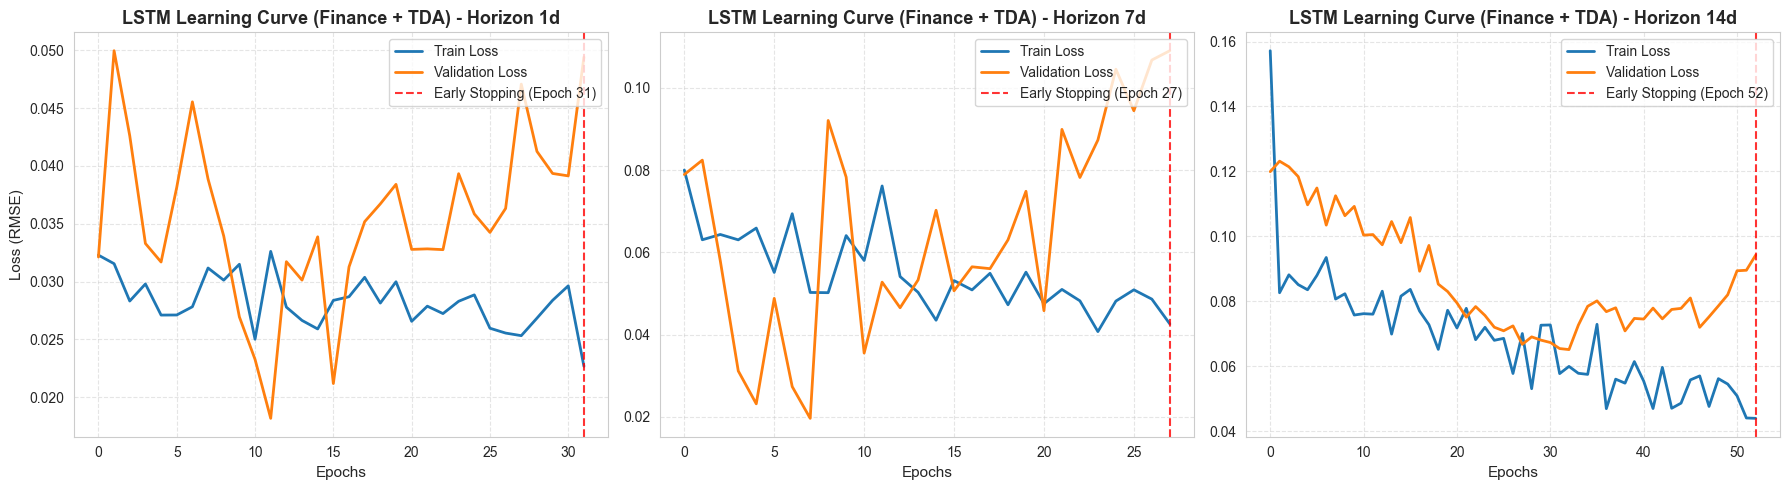

In [14]:
# ==================================================
# CELL 12: VẼ LƯỚI 3 BIỂU ĐỒ LEARNING CURVE NẰM NGANG CỰC ĐẸP
# ==================================================
import matplotlib.pyplot as plt

# Mày chỉ có 3 horizon này
horizons = [1, 7, 14]

# Thiết lập lưới: 1 hàng, 3 cột. Kích thước 18x5 là tỷ lệ vàng để dàn ngang file Word
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bắt đầu vẽ lần lượt vào 3 ô
for i, h_key in enumerate(horizons):
    ax = axes[i]
    
    # Lấy dữ liệu loss từ cái túi lúc nãy
    if h_key in lstm_histories:
        history = lstm_histories[h_key]
        
        # Vẽ 2 đường Loss (Xanh cho Train, Cam cho Val)
        ax.plot(history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
        ax.plot(history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
        
        # Vẽ vạch đỏ Early Stopping chém xuống
        stop_epoch = len(history['val_loss']) - 1
        ax.axvline(x=stop_epoch, color='red', linestyle='--', alpha=0.8, 
                   label=f'Early Stopping (Epoch {stop_epoch})')
        
        # Trang trí chuẩn học thuật tiếng Anh
        ax.set_title(f'LSTM Learning Curve (Finance + TDA) - Horizon {h_key}d', fontsize=13, fontweight='bold')
        ax.set_xlabel('Epochs', fontsize=11)
        
        # Chỉ cần hiện chữ "Loss (RMSE)" ở biểu đồ đầu tiên ngoài cùng bên trái cho đỡ rối
        if i == 0:
            ax.set_ylabel('Loss (RMSE)', fontsize=11)
            
        ax.legend(loc='upper right', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)
    else:
        # Đề phòng mày chưa chạy horizon đó mà đã đòi vẽ
        ax.text(0.5, 0.5, f'No data for {h_key}d', ha='center', va='center', fontsize=12)
        ax.set_title(f'Horizon {h_key}d', fontsize=13)

# Tự động căn chỉnh khoảng cách giữa 3 biểu đồ cho đều nhau
plt.tight_layout()
plt.show()

📈 ĐANG VẼ BIỂU ĐỒ SO SÁNH THỰC TẾ & DỰ ĐOÁN (TẬP TEST 2025-2026)...


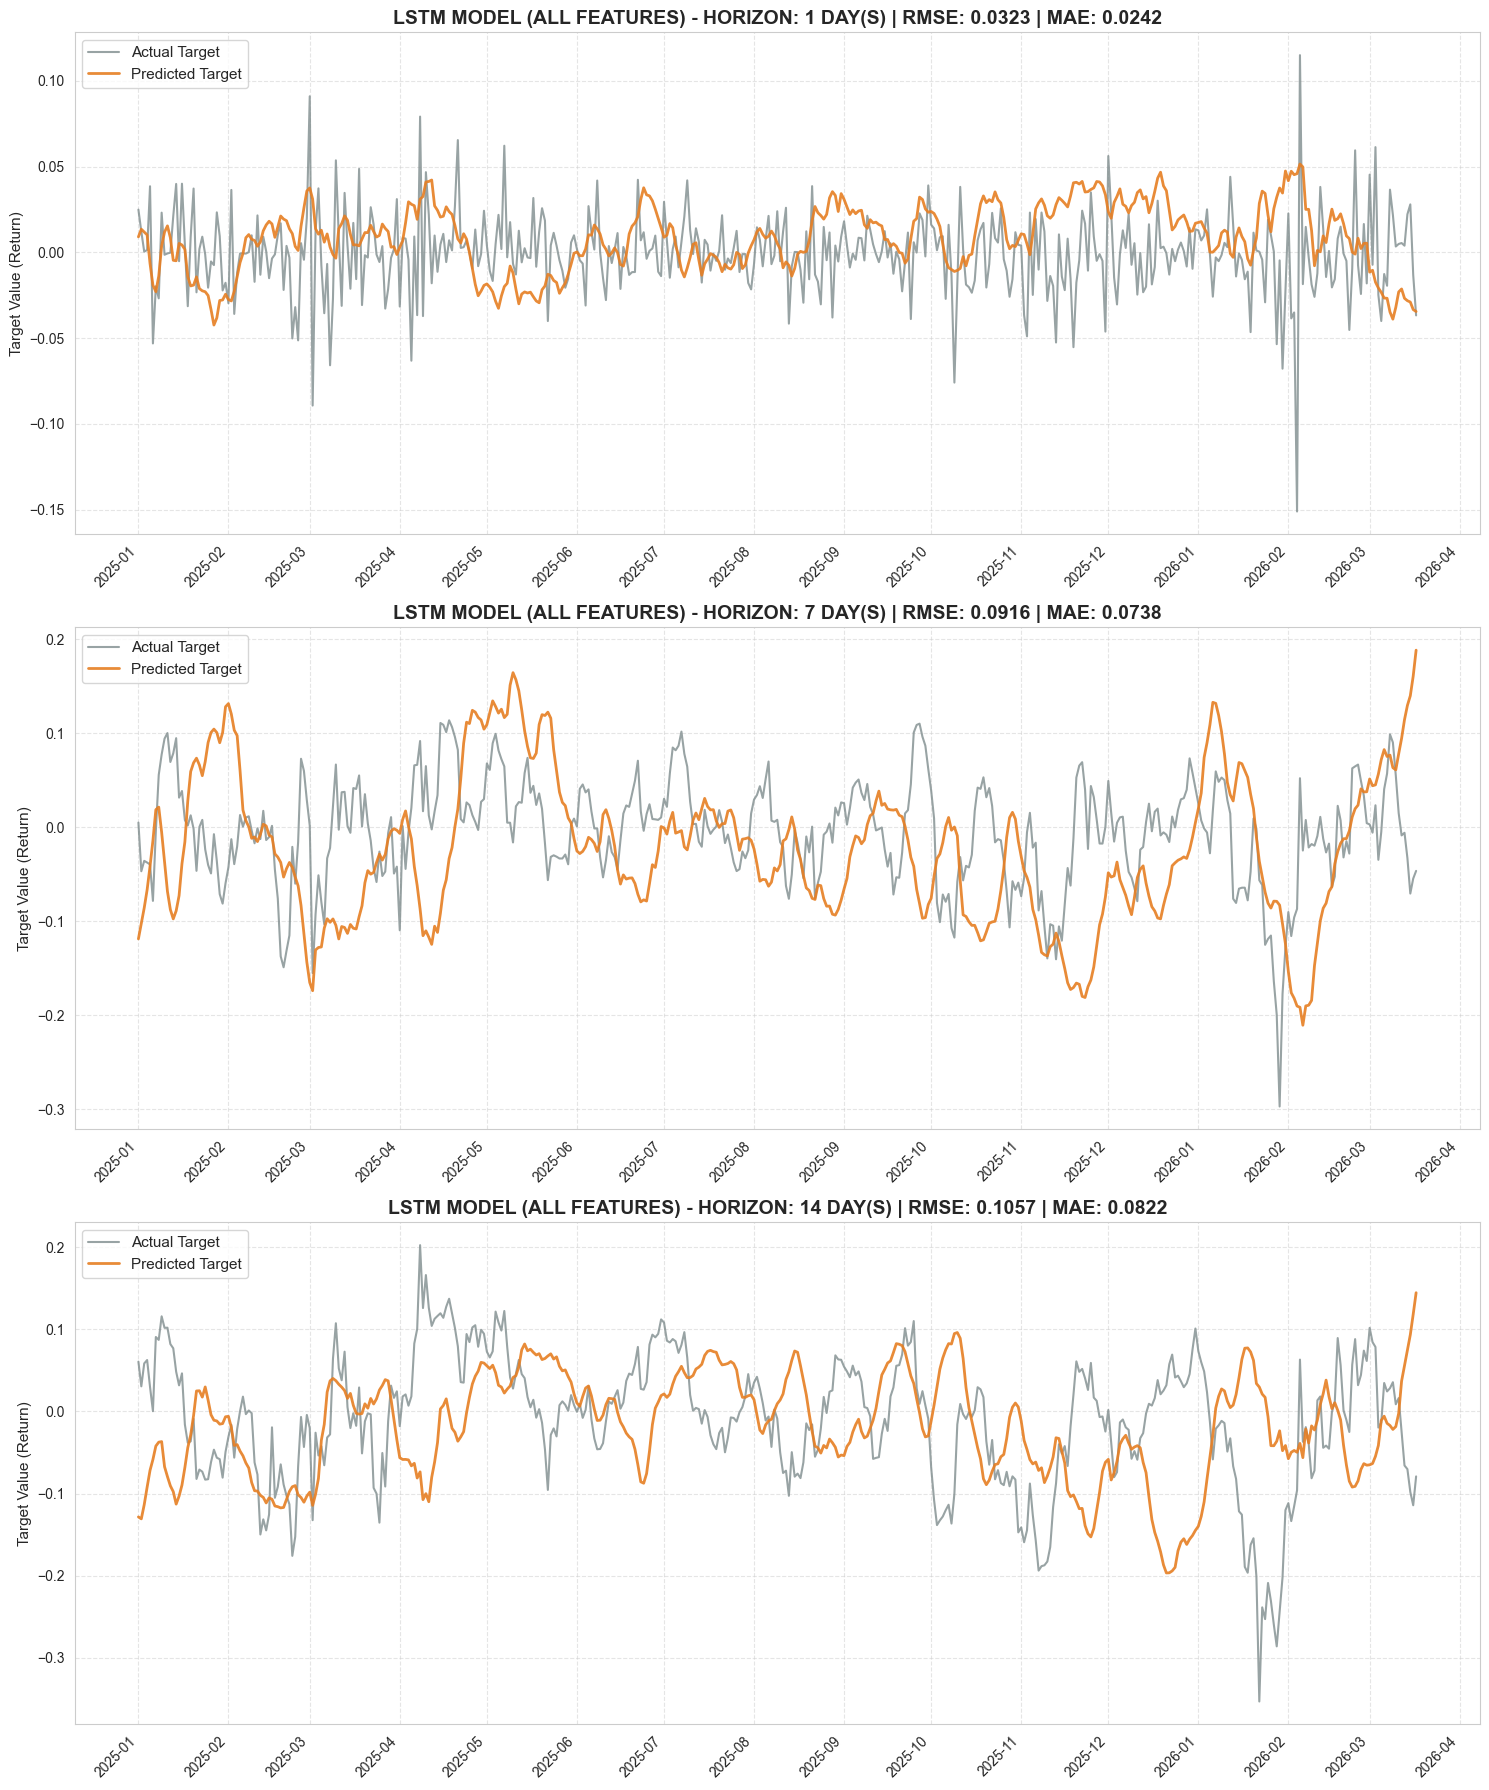

In [15]:
# ==================================================
# CELL 13: TRỰC QUAN HÓA KẾT QUẢ THỰC CHIẾN 2025-2026 (LSTM ALL FEATURES)
# ==================================================

horizons = config.HORIZONS
fig, axes = plt.subplots(len(horizons), 1, figsize=(15, 6 * len(horizons)))
if len(horizons) == 1: axes = [axes]

print("📈 ĐANG VẼ BIỂU ĐỒ SO SÁNH THỰC TẾ & DỰ ĐOÁN (TẬP TEST 2025-2026)...")

for i, h_key in enumerate(horizons):
    ax = axes[i]
    lookback = config.HORIZON_SETTINGS[h_key]['time_steps']
    
    res = test_results[h_key]
    y_true = res['y_true']
    y_pred = res['y_pred']
    rmse = res['metrics']['RMSE']
    mae = res['metrics']['MAE']
    
    # --- SỬA LỖI Ở ĐÂY ---
    # Không cần cắt bỏ 'lookback' nữa vì y_pred giờ đã cover từ ngày đầu tiên của df_test
    test_dates = df_test.index 
    # ---------------------
    
    # Vẽ đường thực tế
    ax.plot(test_dates, y_true, label='Actual Target', color='#7f8c8d', alpha=0.8, linewidth=1.5)
    
    # Vẽ đường dự đoán của LSTM
    ax.plot(test_dates, y_pred, label='Predicted Target', color='#e67e22', alpha=0.9, linewidth=2)
    
    # Format trục
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # --- GẮN THÊM DA VÀO TITLE ---
    ax.set_title(f'LSTM MODEL (ALL FEATURES) - HORIZON: {h_key} DAY(S) | RMSE: {rmse:.4f} | MAE: {mae:.4f}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Target Value (Return)', fontsize=11)
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [16]:
# ==================================================
# CELL 14: XUẤT DỮ LIỆU DỰ BÁO LSTM (FINANCE ONLY) ĐỂ LÀM DM TEST
# ==================================================
import pandas as pd
import os

print("💾 ĐANG LƯU DỮ LIỆU DỰ BÁO LSTM (FINANCE ONLY) RA FILE CSV...")

# Đảm bảo thư mục lưu trữ tồn tại (nếu ông muốn để vào folder riêng)
# if not os.path.exists('model_outputs'): os.makedirs('model_outputs')

for h_key in config.HORIZONS:
    # 1. Lấy data từ túi đựng test_results (đã tạo ở Cell 10)
    if h_key in test_results:
        res = test_results[h_key]
        y_true = res['y_true']
        y_pred = res['y_pred']
        
        # 2. Lấy index thời gian từ df_test
        test_dates = df_test.index 
        
        # Kiểm tra độ dài để tránh lỗi lệch dòng
        if len(test_dates) != len(y_true):
            print(f"⚠️ Cảnh báo: Độ dài index ({len(test_dates)}) và dữ liệu ({len(y_true)}) của Horizon {h_key}d không khớp!")
            continue

        # 3. Tạo DataFrame để xuất file
        df_export = pd.DataFrame({
            'Date': test_dates,
            'y_true': y_true,
            'y_pred_lstm_hybird': y_pred  # Đặt tên cột là lstm_fin để sau này phân biệt với lstm_hybrid
        })
        
        # 4. Lưu file CSV
        file_name = f'DB/test.preds_lstm_hybrid_{h_key}d.csv'
        df_export.to_csv(file_name, index=False)
        
        print(f"  ✅ Đã lưu thành công: {file_name} | Số lượng: {len(df_export)} dòng")
    else:
        print(f"  ❌ Không tìm thấy kết quả cho Horizon {h_key}d trong test_results")

print("-" * 50)
print("🎉 Hoàn tất!")

💾 ĐANG LƯU DỮ LIỆU DỰ BÁO LSTM (FINANCE ONLY) RA FILE CSV...
  ✅ Đã lưu thành công: DB/test.preds_lstm_hybrid_1d.csv | Số lượng: 441 dòng
  ✅ Đã lưu thành công: DB/test.preds_lstm_hybrid_7d.csv | Số lượng: 441 dòng
  ✅ Đã lưu thành công: DB/test.preds_lstm_hybrid_14d.csv | Số lượng: 441 dòng
--------------------------------------------------
🎉 Hoàn tất!


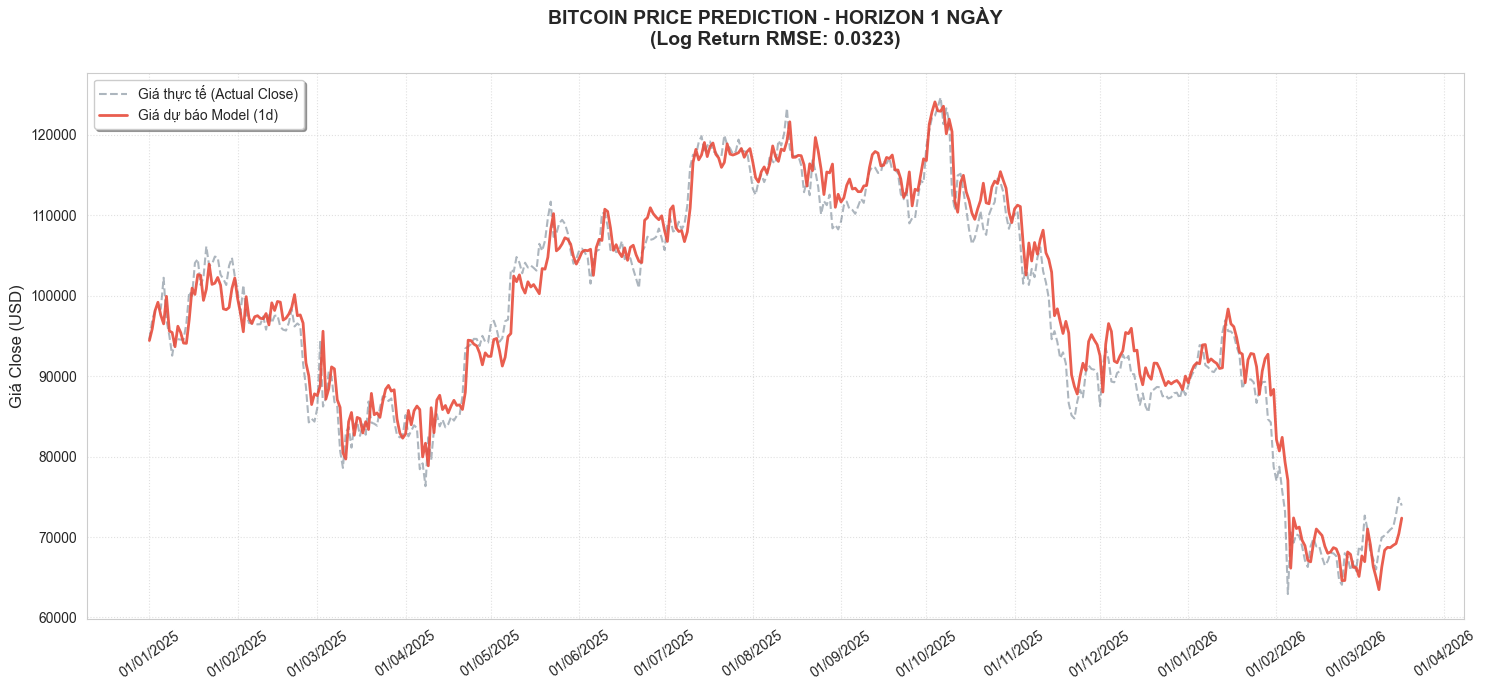

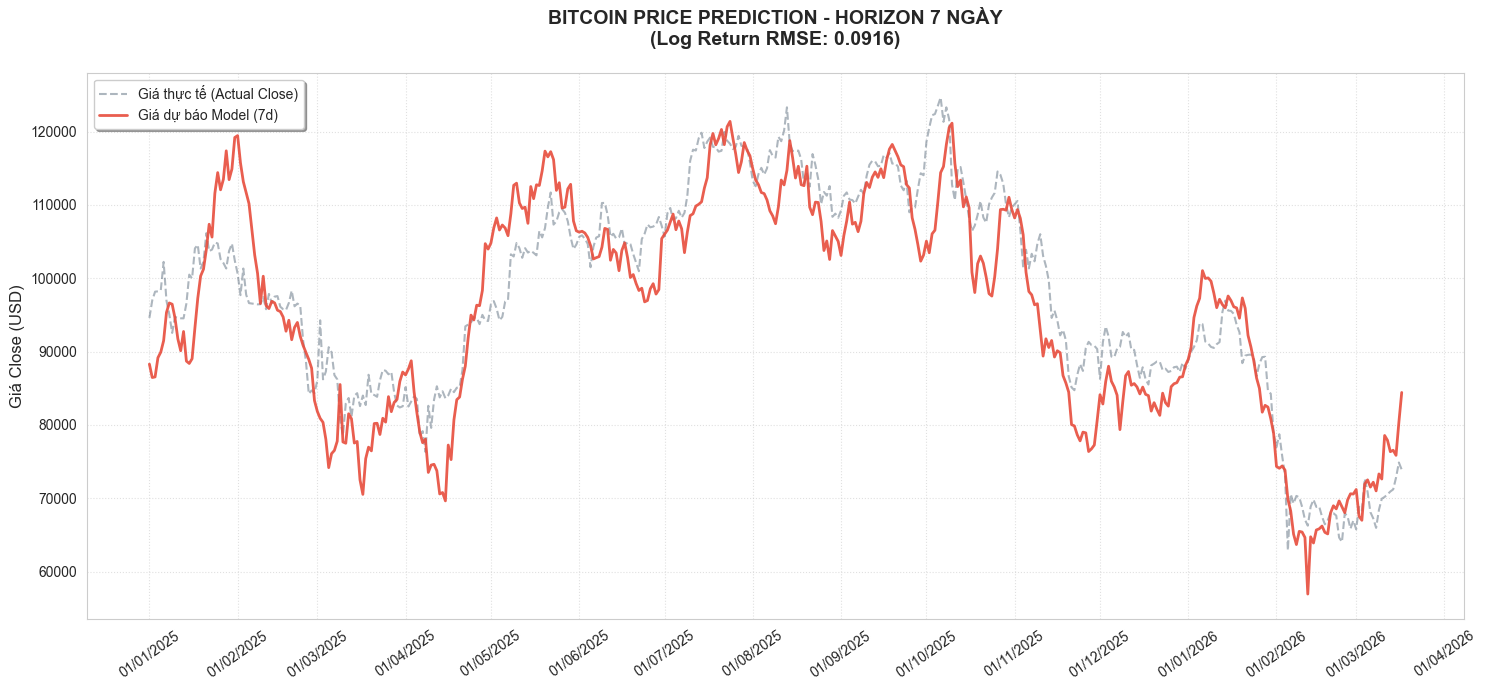

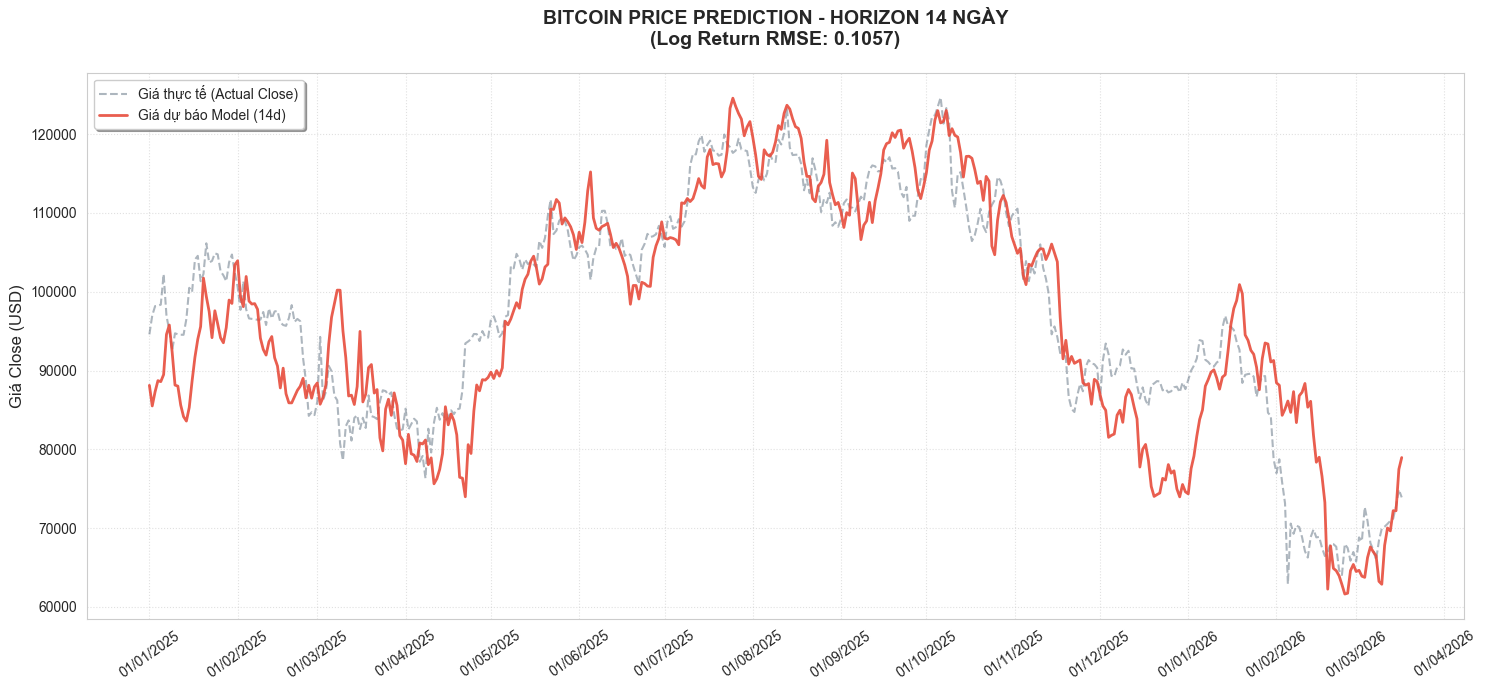

In [17]:
# ==================================================
# CELL 15: TRỰC QUAN HÓA KẾT QUẢ PREDICT THEO CLOSE
# ==================================================

results_to_plot = test_results 

for h_key in config.HORIZONS:
    # 1. Lấy cấu hình
    settings = config.HORIZON_SETTINGS[h_key]
    lookback = settings['time_steps']
    h_days = int(h_key) # 1, 7 hoặc 30
    
    # 2. Lấy log return dự báo từ dictionary
    res = results_to_plot[h_key]
    y_pred_log_ret = res['y_pred']
    
    # --- SỬA LỖI 1: Không cắt bỏ đoạn lookback nữa ---
    # Vì y_pred giờ đã map chính xác từ ngày đầu tiên của tập test
    test_dates = df_test.index
    # -------------------------------------------------
    
    # --- SỬA LỖI 2: Bù dữ liệu mốc để tính giá không bị NaN ---
    # Nối thêm h_days ngày cuối của tập train vào để làm mốc tính base price
    df_train_tail = df_train_val.iloc[-h_days:].copy()
    df_test_extended = pd.concat([df_train_tail, df_test])
    full_close_extended = df_test_extended['close']
    
    # Giá thực tế tại các ngày dự báo
    price_actual = df_test.loc[test_dates, 'close'].values
    
    # Giá mốc lấy từ tập đã nối dài để đảm bảo h_days ngày đầu không bị trống
    price_base = full_close_extended.shift(h_days).loc[test_dates].values
    # ----------------------------------------------------------
    
    # 5. Quy đổi: P_pred = P_base * exp(r_pred)
    price_pred = price_base * np.exp(y_pred_log_ret)
    
    # --- VẼ BIỂU ĐỒ GIÁ ---
    fig, ax = plt.subplots(figsize=(15, 7), facecolor='white')
    
    # Vẽ đường giá thực tế (nét đứt hoặc mờ hơn để làm nền)
    ax.plot(test_dates, price_actual, label='Giá thực tế (Actual Close)', 
            color='#34495e', alpha=0.4, linewidth=1.5, linestyle='--')
    
    # Vẽ đường giá dự báo (nét đậm, màu nổi bật)
    ax.plot(test_dates, price_pred, label=f'Giá dự báo Model ({h_key}d)', 
            color='#e74c3c', alpha=0.9, linewidth=2)
    
    # Thêm các thông số đánh giá lên Title
    da = res.get('dir_accuracy', 0)
    rmse = res['metrics']['RMSE']
    ax.set_title(f'BITCOIN PRICE PREDICTION - HORIZON {h_key} NGÀY\n(Log Return RMSE: {rmse:.4f})', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Định dạng trục
    ax.set_ylabel('Giá Close (USD)', fontsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.xticks(rotation=35)
    
    ax.legend(loc='upper left', frameon=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

### NOTE:
Biểu đồ Price Prediction được tính bằng Price thực tế * exp(log_return_pred), vì vậy nên nhìn giá predict có vẻ đi rất gần với giá thực tế.